### Retinal vessel detection 
Stanisław Marszałek 160167 </br>
Łukasz Przykłota 159440

### Importing libraries and creating constants

In [1]:
import numpy as np
from copy import deepcopy
import os 
import ipywidgets as widgets
from IPython.display import display
import warnings
import cv2

from image_processing import read_img,show_img,draw_vessels
from classic_version import classic_vessel_segmentation
from simple_statistics import create_confusions_matrix

#Supressing warrnigns
warnings.filterwarnings("ignore")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

### Choosing method and images

In [2]:
method=widgets.Combobox(

    placeholder='Choose the method to find vessels',
    options=["Sato filtr","Random Forrest Model","UNet (Neural Network)"],
    description='Method',
    ensure_option=True,
    disabled=False,
    layout=widgets.Layout(width='auto')
)
images = widgets.SelectMultiple(
    # hold CTRL to choose more than one
    options=input_images,
    value=[],
    description='Images',
    disabled=False
)
show_confussion_matrix=widgets.Checkbox(
    value=False,
    description='Show confussion matrix',
    disabled=False,
    layout=widgets.Layout(width='auto')
)
sliders=widgets.VBox([method,show_confussion_matrix,images],layout=widgets.Layout(width='45%'))
display(sliders)

### Choosing paramteres/models

In [16]:
if method.value!="":
    if method.value=="Sato filtr":
        threshold=widgets.FloatSlider(
        value=0.0085,
        min=0.001,
        max=0.02,
        step=0.0005,
        description='Threshold:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.4f',
        layout=widgets.Layout(width='auto')
        )
        median_kernel_size=widgets.IntSlider(
        value=11,
        min=3,
        max=21,
        step=2,
        description='Median Kernel Size:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        layout=widgets.Layout(width='auto')
        )
        filling_kernel_size=widgets.IntSlider(
        value=17,
        min=3,
        max=21,
        step=2,
        description='Filling Kernel Size:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        layout=widgets.Layout(width='auto')
        )

        sliders=widgets.VBox([threshold,median_kernel_size,filling_kernel_size],layout=widgets.Layout(width='45%'))
       
        
    else:
        if method.value=="Random Forrest Model":
            models=[SAVED_MODELS+"/"+file.name for file in os.scandir(SAVED_MODELS) if file.is_file() and file.name.endswith("pkl")]
        
        elif method.value=="UNet (Neural Network)":
            models=[SAVED_MODELS+"/"+file.name for file in os.scandir(SAVED_MODELS) if file.is_file() and file.name.endswith("pth")]
        
        model=widgets.Combobox(
            placeholder='Choose the model to find vessels',
            options=models,
            description='Model',
            ensure_option=True,
            disabled=False,
            layout=widgets.Layout(width='auto')
        )
        sliders=widgets.VBox([model],layout=widgets.Layout(width='45%'))
    
    display(sliders)   
    
    

### Looking for vessels

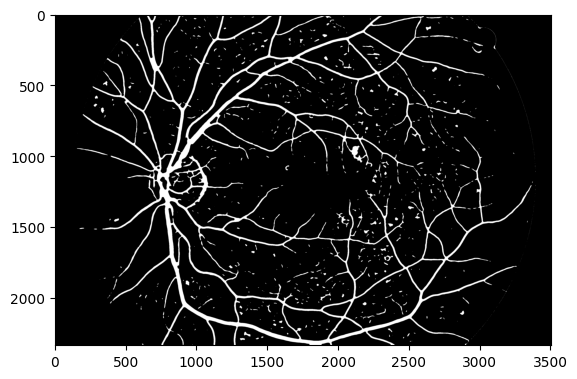

SATO


KeyboardInterrupt: 

In [ ]:
if method.value!="" and images.value!=():
    data=[[str(image_path)] for image_path in images.value]
    #Looking for FOV paths
    for single_list in data:
        name=single_list[0].replace(INPUT_DIR+"/","").replace(".jpg","").replace(".JPG","")
        for fov_path in mask_images:
            if name in fov_path:
                single_list.append(fov_path)
                break
        else:
            raise ValueError("FOV musk not found\nPlease check if the FOV mask is in `mask` directory\n and if its name suits the naming pattern")

        if show_confussion_matrix.value:
            for expert_path in manual_images:
                if name in expert_path:
                    single_list.append(expert_path)
                    break
            else:
                raise ValueError("Expert musk not found\nPlease check if the expert mask is in `manual1` directory\n and if its name suits the naming pattern")
    
    for single_list in data:
        img=read_img(single_list[0])
        fov_mask=read_img(single_list[1])

        

        if method.value== "Sato filtr":
            img_copy=deepcopy(img)
            vessels=classic_vessel_segmentation(img,fov_mask,threshold=0.009)
            print("SATO")
        
        elif method.value=="Random Forrest Model":
            img_copy=deepcopy(img)
            print("Forrest")
        
        elif method.value=="UNet (Neural Network)":
            if len(fov_mask.shape)>1:
                fov_mask=fov_mask[:,:,1]
            
            img = np.transpose(img, (2, 0, 1))          # HWC -> CHW
            img = np.expand_dims(img, axis=0)           # CHW -> NCHW
            img_copy=deepcopy(img)
            
            print("Unet")
        
        if show_confussion_matrix.value:
            expert_mask=read_img(single_list[2])
            expert_mask=np.where(expert_mask>0,1,0).astype(np.uint8)
            if method.value=="UNet (Neural Network)":
                #TODO zrobic tutaj resize na 512 na 512
                pass

